In [1]:
import pandas as pd
from sklearn.datasets import load_digits
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('C:/Users/Admin/Desktop/Data Mining/data_for_kdm912s_assessment_3_2025/task2Data.csv')

In [3]:
dataset

,Age,Work-class,Id,Education,Education-num,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,Namibia,<=800K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,Namibia,<=800K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,Namibia,<=800K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,Namibia,<=800K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Botswana,<=800K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,Namibia,<=800K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,Namibia,>800K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,Namibia,<=800K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,Namibia,<=800K


In [4]:
dataset1 = dataset.copy()

In [5]:
dataset1

,Age,Work-class,Id,Education,Education-num,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,Namibia,<=800K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,Namibia,<=800K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,Namibia,<=800K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,Namibia,<=800K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Botswana,<=800K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,Namibia,<=800K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,Namibia,>800K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,Namibia,<=800K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,Namibia,<=800K


In [6]:
dataset1["Occupation"].str.lstrip(["/","..."])

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
32556   NaN
32557   NaN
32558   NaN
32559   NaN
32560   NaN
Name: Occupation, Length: 32561, dtype: float64

In [7]:
dataset1["Occupation"] = dataset1["Occupation"].replace(['?', 'nan', np.nan], 'unknown')
dataset1["Work-class"] = dataset1["Work-class"].replace(['?', 'nan', np.nan], 'unknown')

In [8]:
mode_value = dataset1["Native country"].mode()[0]
dataset1["Native country"].fillna(mode_value, inplace=True)
print(f"Missing values replaced with mode: {mode_value}")


Missing values replaced with mode:  Namibia


C:\Users\Admin\AppData\Local\Temp\ipykernel_20108\3212324966.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset1["Native country"].fillna(mode_value, inplace=True)


In [9]:
print("\nDataset info:")
print(dataset1.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Work-class      32561 non-null  object
 2   Id              32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education-num   32561 non-null  int64 
 5   Marital-status  32561 non-null  object
 6   Occupation      32561 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital-gain    32561 non-null  int64 
 11  Capital-loss    32561 non-null  int64 
 12  Hours-per-week  32561 non-null  int64 
 13  Native country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [10]:
dataset1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Work-class      32561 non-null  object
 2   Id              32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education-num   32561 non-null  int64 
 5   Marital-status  32561 non-null  object
 6   Occupation      32561 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital-gain    32561 non-null  int64 
 11  Capital-loss    32561 non-null  int64 
 12  Hours-per-week  32561 non-null  int64 
 13  Native country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [11]:
print("Missing values after cleaning:")
print(dataset1.isnull().sum())

Missing values after cleaning:
Age               0
Work-class        0
Id                0
Education         0
Education-num     0
Marital-status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital-gain      0
Capital-loss      0
Hours-per-week    0
Native country    0
Income            0
dtype: int64


In [12]:
#dataset1 = dataset1.drop(columns=['Id'])

In [13]:
dataset1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Work-class      32561 non-null  object
 2   Id              32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education-num   32561 non-null  int64 
 5   Marital-status  32561 non-null  object
 6   Occupation      32561 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital-gain    32561 non-null  int64 
 11  Capital-loss    32561 non-null  int64 
 12  Hours-per-week  32561 non-null  int64 
 13  Native country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [14]:
# Convert continuous variables to categorical bins
# Age bins
dataset1['Age_bin'] = pd.cut(dataset1['Age'], 
                                bins=[0, 25, 35, 45, 60, 75, 100],
                                labels=['Young', 'Young-Adult', 'Middle-Aged', 'Senior', 'Elderly', 'Very-Elderly'])

# Education-num bins (already has education level, but we'll use the numeric version)
dataset1['Education_level'] = pd.cut(dataset1['Education-num'],
                                       bins=[0, 7, 10, 12,  16, 20],
                                       labels=['Low', 'Primary-School', 'High-School', 'Bachelors+', 'Post-Graduate'])

# Hours-per-week bins
dataset1['Hours_bin'] = pd.cut(dataset1['Hours-per-week'],
                                 bins=[0, 20, 35, 45, 60, 100],
                                 labels=['Part-time', 'Reduced', 'Full-time', 'Overtime', 'Excessive'])

# Capital-gain and Capital-loss bins
dataset1['Capital_gain_bin'] = pd.cut(dataset1['Capital-gain'],
                                        bins=[-1, 0, 5000, 10000, 50000, 100000],
                                        labels=['No-gain', 'Small-gain', 'Medium-gain', 'Large-gain', 'Very-large-gain'])

dataset1['Capital_loss_bin'] = pd.cut(dataset1['Capital-loss'],
                                       bins=[-1, 0, 1000, 2000, 5000, 10000],
                                       labels=['No-loss', 'Small-loss', 'Medium-loss', 'Large-loss', 'Very-large-loss'])

# Select relevant categorical columns for association rules
candidate_columns = ['Work-class', 'Education', 'Marital-status', 'Occupation', 
                    'Relationship', 'Race', 'Sex', 'Native country', 'Income',
                    'Age_bin', 'Education_level', 'Hours_bin', 'Capital_gain_bin', 'Capital_loss_bin']

# Prepare transaction data
transactions = []
for i in range(len(dataset1)):
    transaction = []
    for col in candidate_columns:
        if pd.notna(dataset1.iloc[i][col]):
            transaction.append(f"{col}_{dataset1.iloc[i][col]}")
    transactions.append(transaction)

print(f"Total transactions: {len(transactions)}")
print(f"Sample transaction: {transactions[0]}")

Total transactions: 32561
Sample transaction: ['Work-class_ State-gov', 'Education_ Bachelors', 'Marital-status_ Never-married', 'Occupation_ Adm-clerical', 'Relationship_ Not-in-family', 'Race_ White', 'Sex_ Male', 'Native country_ Namibia', 'Income_ <=800K', 'Age_bin_Middle-Aged', 'Education_level_Bachelors+', 'Hours_bin_Full-time', 'Capital_gain_bin_Small-gain', 'Capital_loss_bin_No-loss']


In [15]:
dataset1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               32561 non-null  int64   
 1   Work-class        32561 non-null  object  
 2   Id                32561 non-null  int64   
 3   Education         32561 non-null  object  
 4   Education-num     32561 non-null  int64   
 5   Marital-status    32561 non-null  object  
 6   Occupation        32561 non-null  object  
 7   Relationship      32561 non-null  object  
 8   Race              32561 non-null  object  
 9   Sex               32561 non-null  object  
 10  Capital-gain      32561 non-null  int64   
 11  Capital-loss      32561 non-null  int64   
 12  Hours-per-week    32561 non-null  int64   
 13  Native country    32561 non-null  object  
 14  Income            32561 non-null  object  
 15  Age_bin           32561 non-null  category
 16  Education_level   3256

In [16]:
# Convert to one-hot encoded format
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Encoded dataset shape: {df_encoded.shape}")

# Find frequent itemsets with minimum support of 0.5
frequent_itemsets = apriori(df_encoded, min_support=0.5, use_colnames=True)
print(f"Number of frequent itemsets: {len(frequent_itemsets)}")

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
print(f"Number of association rules: {len(rules)}")

# Display top rules
rules = rules.sort_values(['confidence', 'support'], ascending=[False, False])
print("\nTop 10 association rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Encoded dataset shape: (32561, 95)
Number of frequent itemsets: 73
Number of association rules: 404

Top 10 association rules:
                                           antecedents  \
154              (Work-class_ Private, Income_ <=800K)   
237  (Capital_gain_bin_No-gain, Work-class_ Private...   
21                                    (Income_ <=800K)   
142          (Native country_ Namibia, Income_ <=800K)   
148                      (Race_ White, Income_ <=800K)   
58          (Capital_gain_bin_No-gain, Income_ <=800K)   
335  (Native country_ Namibia, Race_ White, Income_...   
209  (Capital_gain_bin_No-gain, Native country_ Nam...   
223  (Capital_gain_bin_No-gain, Race_ White, Income...   
374  (Capital_gain_bin_No-gain, Native country_ Nam...   

                    consequents   support  confidence      lift  
154  (Capital_loss_bin_No-loss)  0.529007    0.971353  1.018885  
237  (Capital_loss_bin_No-loss)  0.507632    0.970183  1.017657  
21   (Capital_loss_bin_No-loss)  0.7

In [17]:
# Analyze frequent itemsets
print("Most frequent individual items:")
item_support = {}
for col in df_encoded.columns:
    item_support[col] = df_encoded[col].mean()

# Sort by support
sorted_items = sorted(item_support.items(), key=lambda x: x[1], reverse=True)
for item, support in sorted_items[:10]:
    print(f"{item}: {support:.3f}")



Most frequent individual items:
Capital_loss_bin_No-loss: 0.953
Capital_gain_bin_No-gain: 0.917
Native country_ Namibia: 0.911
Race_ White: 0.854
Income_ <=800K: 0.759
Work-class_ Private: 0.697
Sex_ Male: 0.669
Hours_bin_Full-time: 0.569
Education_level_Primary-School: 0.560
Marital-status_ Married-civ-spouse: 0.460


In [25]:
# Convert to one-hot encoded format
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Encoded dataset shape: {df_encoded.shape}")
print(f"Number of unique items: {len(te.columns_)}")

# Find frequent itemsets with minimum support of 0.5 (50%)
print("\nFinding frequent itemsets...")
frequent_itemsets = apriori(df_encoded, min_support=0.5, use_colnames=True)
print(f"Number of frequent itemsets: {len(frequent_itemsets)}")

if len(frequent_itemsets) == 0:
    print("No frequent itemsets found with support ≥ 0.5. Try lower support threshold.")
else:
    # Display top frequent itemsets
    print("\nTop 10 frequent itemsets:")
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
    print(frequent_itemsets.sort_values('support', ascending=False).head(10))
    
    # Generate association rules with minimum confidence of 0.5 (50%)
    print("\nGenerating association rules...")
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
    print(f"Number of association rules generated: {len(rules)}")
    
    if len(rules) > 0:
        # Sort rules by confidence and support
        rules = rules.sort_values(['confidence', 'support'], ascending=[False, False])
        
        # Display all rules that meet the criteria
        print(f"\nALL Association Rules (support ≥ 0.5, confidence ≥ 0.5):")
        print("=" * 80)
        
        for idx, rule in rules.iterrows():
            antecedents = list(rule['antecedents'])
            consequents = list(rule['consequents'])
            support = rule['support']
            confidence = rule['confidence']
            lift = rule['lift']
            
            print(f"Rule {idx + 1}:")
            print(f"  IF {antecedents}")
            print(f"  THEN {consequents}")
            print(f"  Support: {support:.3f}, Confidence: {confidence:.3f}, Lift: {lift:.3f}")
            print("-" * 60)

Encoded dataset shape: (32561, 95)
Number of unique items: 95

Finding frequent itemsets...
Number of frequent itemsets: 73

Top 10 frequent itemsets:
     support                                           itemsets  length
1   0.953349                         (Capital_loss_bin_No-loss)       1
0   0.916710                         (Capital_gain_bin_No-gain)       1
5   0.910629                          (Native country_ Namibia)       1
9   0.870059  (Capital_loss_bin_No-loss, Capital_gain_bin_No...       2
20  0.867541  (Capital_loss_bin_No-loss, Native country_ Nam...       2
6   0.854274                                      (Race_ White)       1
13  0.833451  (Native country_ Namibia, Capital_gain_bin_No-...       2
21  0.812936            (Capital_loss_bin_No-loss, Race_ White)       2
29  0.799330             (Native country_ Namibia, Race_ White)       2
36  0.790363  (Capital_loss_bin_No-loss, Native country_ Nam...       3

Generating association rules...
Number of association ru

In [30]:
# Additional analysis for better insights
if len(rules) > 0:
    # Summary statistics
    print("\n" + "="*50)
    print("ASSOCIATION RULES SUMMARY")
    print("="*50)
    print(f"Total rules meeting criteria: {len(rules)}")
    print(f"Average confidence: {rules['confidence'].mean():.3f}")
    print(f"Average support: {rules['support'].mean():.3f}")
    print(f"Average lift: {rules['lift'].mean():.3f}")
    
    # Rules with highest confidence
    print(f"\nTop 5 rules by confidence:")
    top_conf_rules = rules.nlargest(5, 'confidence')
    for i, (idx, rule) in enumerate(top_conf_rules.iterrows(), 1):
        print(f"{i}. IF {list(rule['antecedents'])} THEN {list(rule['consequents'])}")
        print(f"   (Confidence: {rule['confidence']:.3f}, Support: {rule['support']:.3f})")
    
    # Rules with highest support
    print(f"\nTop 5 rules by support:")
    top_support_rules = rules.nlargest(5, 'support')
    for i, (idx, rule) in enumerate(top_support_rules.iterrows(), 1):
        print(f"{i}. IF {list(rule['antecedents'])} THEN {list(rule['consequents'])}")
        print(f"   (Support: {rule['support']:.3f}, Confidence: {rule['confidence']:.3f})")


    # Strong rules (high confidence and lift > 1)
    strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1.2)]
    print(f"\nStrong rules (confidence > 0.5 and lift > 1.2): {len(strong_rules)}")
    
else:
    print("No association rules found meeting the minimum thresholds.")
    print("Consider lowering the minimum support or confidence thresholds.")


ASSOCIATION RULES SUMMARY
Total rules meeting criteria: 404
Average confidence: 0.779
Average support: 0.587
Average lift: 1.013

Top 5 rules by confidence:
1. IF ['Income_ <=800K', 'Work-class_ Private'] THEN ['Capital_loss_bin_No-loss']
   (Confidence: 0.971, Support: 0.529)
2. IF ['Capital_gain_bin_No-gain', 'Work-class_ Private', 'Income_ <=800K'] THEN ['Capital_loss_bin_No-loss']
   (Confidence: 0.970, Support: 0.508)
3. IF ['Income_ <=800K'] THEN ['Capital_loss_bin_No-loss']
   (Confidence: 0.970, Support: 0.736)
4. IF ['Native country_ Namibia', 'Income_ <=800K'] THEN ['Capital_loss_bin_No-loss']
   (Confidence: 0.969, Support: 0.665)
5. IF ['Income_ <=800K', 'Race_ White'] THEN ['Capital_loss_bin_No-loss']
   (Confidence: 0.969, Support: 0.616)

Top 5 rules by support:
1. IF ['Capital_gain_bin_No-gain'] THEN ['Capital_loss_bin_No-loss']
   (Support: 0.870, Confidence: 0.949)
2. IF ['Capital_loss_bin_No-loss'] THEN ['Capital_gain_bin_No-gain']
   (Support: 0.870, Confidence: 0.

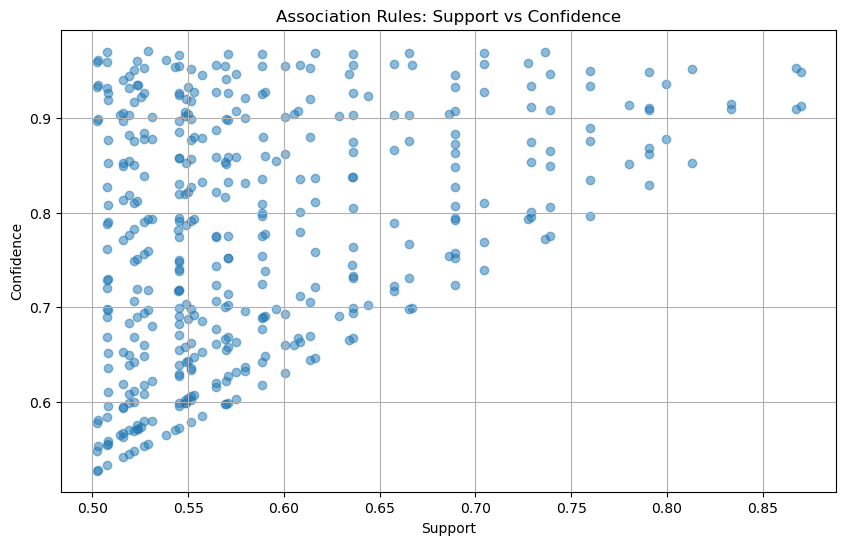

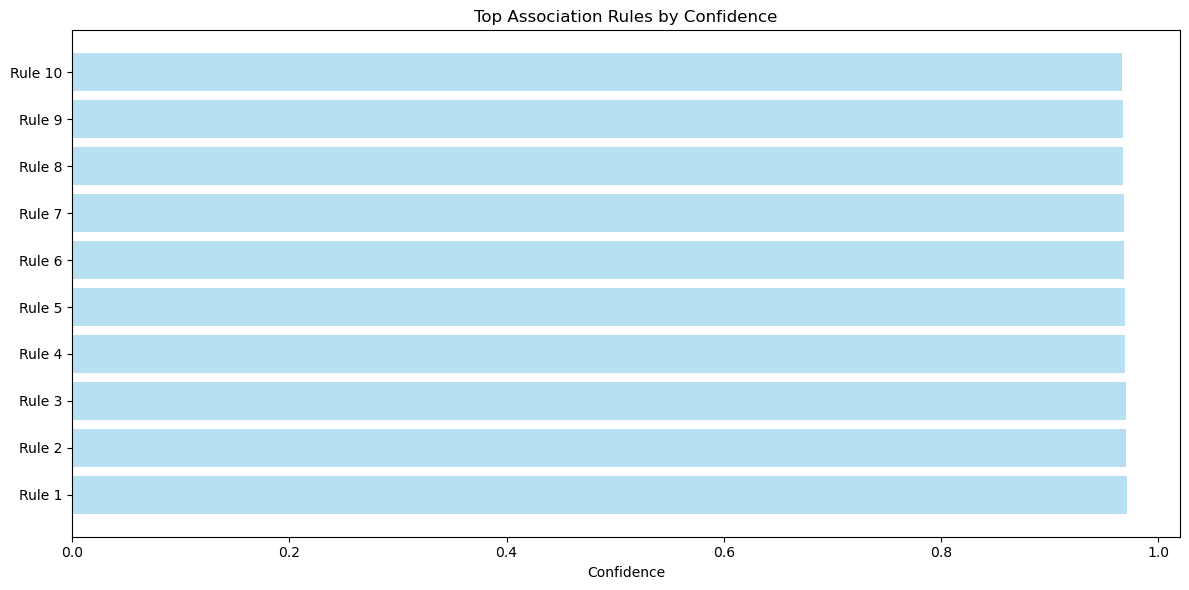

In [28]:
# Optional: Create visualizations
if len(rules) > 0:
    # Scatter plot of support vs confidence
    plt.figure(figsize=(10, 6))
    plt.scatter(rules['support'], rules['confidence'], alpha=0.5)
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Association Rules: Support vs Confidence')
    plt.grid(True)
    plt.show()
    
    # Top rules visualization
    if len(rules) > 10:
        top_rules = rules.head(10)
    else:
        top_rules = rules
        
    plt.figure(figsize=(12, 6))
    y_pos = np.arange(len(top_rules))
    plt.barh(y_pos, top_rules['confidence'], alpha=0.6, color='skyblue')
    plt.yticks(y_pos, [f"Rule {i+1}" for i in range(len(top_rules))])
    plt.xlabel('Confidence')
    plt.title('Top Association Rules by Confidence')
    plt.tight_layout()
    plt.show()